Device: cpu

Loading pretrained model...


Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!

Upload an image for caption generation:


Saving download.jpg to download.jpg

Image selected: download.jpg


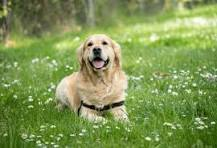


IMAGE CAPTIONING RESULT
Caption: a brown dog sitting in a field of grass 

MODEL INFORMATION
Vision Encoder : ViT
Text Decoder   : GPT-2
Decoding       : Beam Search
Number of Beams: 4
Maximum Length : 30


In [2]:
# ============================================================
# EX 7: IMAGE CAPTIONING USING ViT-GPT2 ARCHITECTURE
# AI23531 - Deep Learning
# ============================================================

# Install required libraries
!pip -q install transformers accelerate

# ------------------------------------------------------------
# 1. Import Required Libraries
# ------------------------------------------------------------
import torch
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
from IPython.display import display
import os

# ------------------------------------------------------------
# 2. Select Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ------------------------------------------------------------
# 3. Load Pretrained Image Captioning Model
# ------------------------------------------------------------
model_name = "nlpconnect/vit-gpt2-image-captioning"

print("\nLoading pretrained model...")

model = VisionEncoderDecoderModel.from_pretrained(model_name)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

model.to(device)
model.eval()

print("Model loaded successfully!")

# ------------------------------------------------------------
# 4. Define Caption Generation Function
# ------------------------------------------------------------
def generate_caption(image_path, max_length=30, num_beams=4):

    image = Image.open(image_path).convert("RGB")

    # Display input image
    display(image)

    # Convert image into model input
    pixel_values = processor(
        images=image,
        return_tensors="pt"
    ).pixel_values.to(device)

    # Generate caption using beam search
    output_ids = model.generate(
        pixel_values,
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True
    )

    # Convert generated tokens into text
    caption = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    return caption

# ------------------------------------------------------------
# 5. Upload an Image in Google Colab
# ------------------------------------------------------------
from google.colab import files

print("\nUpload an image for caption generation:")
uploaded = files.upload()

# Get uploaded image filename
img_path = next(iter(uploaded))

print("\nImage selected:", img_path)

# ------------------------------------------------------------
# 6. Generate Caption
# ------------------------------------------------------------
caption = generate_caption(img_path)

print("\n==============================")
print("IMAGE CAPTIONING RESULT")
print("==============================")
print("Caption:", caption)

# ------------------------------------------------------------
# 7. Experiment Information
# ------------------------------------------------------------
print("\n==============================")
print("MODEL INFORMATION")
print("==============================")
print("Vision Encoder : ViT")
print("Text Decoder   : GPT-2")
print("Decoding       : Beam Search")
print("Number of Beams:", 4)
print("Maximum Length :", 30)